### Step 3 - Spatial Resolution of Lineages
In this tutorial, you'll trace one specific variant family, `EG.5*`, across San Diego County using the clinical and wastewater data from Step 2: how much of the clinical signal in each zip code was `EG.5*` during weeks 35-38 of 2023, and how much of the wastewater signal at each treatment plant was `EG.5*` over that same window. Both plots share the same color scale, so they can be read side by side. As before, run each cell in order until you've completed the notebook.

#### Imports
Alongside pandas, seaborn, and matplotlib, this notebook needs `geopandas` to work with zip code boundary polygons, `pygris` to fetch those boundaries directly from the US Census Bureau's TIGER/Line files, and `matplotlib`'s colormap utilities to build the shared color scale used by both plots.

In [23]:
import json
import os

import geopandas as gpd
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pygris import counties, zctas

#### Load the clinical metadata
Same file as Step 2: one row per clinical sample, with a collection date, an assigned Pango lineage, and a zip code. We also compute an ISO year-week (`year_week`), the same way Step 2 does, since we'll be restricting to a specific 3-week window.

In [24]:
clinical_metadata = pd.read_csv("../data/clinical_metadata.csv")
clinical_metadata["zipcode"] = clinical_metadata["zipcode"].astype(str)
clinical_metadata["year_week"] = pd.to_datetime(clinical_metadata["collection_date"]).dt.strftime("%G-W%V")
clinical_metadata.head()

,sample_id,collection_date,lineage,zipcode,year_week
0,SRR26500334,2023-09-01,GK.4,91911,2023-W35
1,SRR26500335,2023-09-01,GJ.1.2,92021,2023-W35
2,SRR26500336,2023-09-01,FL.1.5.1,91977,2023-W35
3,SRR26500337,2023-09-01,FU.2,91977,2023-W35
4,SRR26500338,2023-09-01,HW.1.1,92143,2023-W35


#### Collapse lineages into variant families
Step 2 showed that thresholding on raw, fine-grained Pango lineage names leaves hundreds of near-identical sub-lineages and is not easily visualized. Collapsing lineages using `data/curated_lineages.json` fixes this.

In [25]:
with open("../data/curated_lineages.json") as f:
    curated_lineages = json.load(f)

# broadest clades first, so more specific descendant lists overwrite them below
curated_lineages = sorted(curated_lineages, key=lambda rec: len(rec.get("pango_descendants", [])), reverse=True)

lineage_to_variant = {}
for record in curated_lineages:
    who_name = record.get("who_name")
    if who_name is None:
        continue
    for descendant in record.get("pango_descendants", []):
        lineage_to_variant[descendant] = who_name

clinical_metadata["variant"] = clinical_metadata["lineage"].map(lineage_to_variant).fillna("Other")

EG5_NAME = next(v for v in lineage_to_variant.values() if v.startswith("EG.5"))
print(f"EG.5* clade label: {EG5_NAME}")
clinical_metadata["variant"].value_counts()

EG.5* clade label: EG.5* [Omicron (EG.5.X)]


variant
EG.5* [Omicron (EG.5.X)]              397
XBB.1.16* [Omicron (XBB.1.16.X)]      196
XBB.1.5* [Omicron (XBB.1.5.X)]        129
XBB.1.9.1* [Omicron (XBB.1.9.1.X)]    108
XBB.2.3* (XBB.2.3.X)                   58
Other                                  24
XBB* (XBB.X)                           22
XBB.1.9.2* [Omicron (XBB.1.9.2.X)]     18
BA.2.86* (BA.2.86.X)                    5
CH.1.1* [Omicron (CH.1.1.X)]            1
Name: count, dtype: int64

#### Restrict to San Diego County
The `zipcode` column is real-world clinical intake data, and it isn't perfectly clean: some rows have missing values, and a few contain zip codes from entirely different states (data entry mistakes). Even among well-formed 5-digit codes, a handful are legitimate US zip codes that simply aren't in San Diego County.

Rather than trust the zip code *strings* in the data, we fetch San Diego County's actual boundary from the Census Bureau and the boundaries of every zip code in the country, then keep only the ZCTAs that spatially intersect the county. Any clinical sample whose zip code isn't in that set — whether due to bad data or a genuinely out-of-county address — gets dropped.

In [26]:
ca_counties = counties(state="CA", cb=True, year=2020, cache=True)
san_diego_county = ca_counties[ca_counties["NAME"] == "San Diego"]

all_zctas = zctas(cb=True, year=2020, cache=True)
san_diego_county_proj = san_diego_county.to_crs(all_zctas.crs)
san_diego_zctas = gpd.sjoin(
    all_zctas, san_diego_county_proj[["geometry"]], predicate="intersects", how="inner"
)
san_diego_zctas = san_diego_zctas[["ZCTA5CE20", "geometry"]].rename(columns={"ZCTA5CE20": "zipcode"})

in_san_diego_county = clinical_metadata["zipcode"].isin(san_diego_zctas["zipcode"])
n_dropped = (~in_san_diego_county).sum()
print(f"dropping {n_dropped} / {len(clinical_metadata)} samples with a missing, malformed, "
      "or out-of-county zip code")

clinical_sd = clinical_metadata[in_san_diego_county].copy()

Using FIPS code '06' for input 'CA'
dropping 72 / 958 samples with a missing, malformed, or out-of-county zip code


#### Restrict to weeks 35-38, 2023
A single ISO week turns out to be too thin a slice on its own — wastewater in particular has only 2 samples total in week 35 (and zero at the Encina plant that week). Widening to a 4-week window (weeks 35-38) gives every zip code and every treatment plant at least a few samples behind its estimate, while still describing a specific, narrow slice of time rather than the whole study period.

In [34]:
ANALYSIS_WEEKS = ["2023-W35", "2023-W36", "2023-W37", "2023-W38"]

clinical_window = clinical_sd[clinical_sd["year_week"].isin(ANALYSIS_WEEKS)].copy()
print(f"{len(clinical_window)} clinical samples in weeks 35-38, 2023")

493 clinical samples in weeks 35-38, 2023


#### Summarize by zip code: EG.5* share and sample count
For each zip code, compute what percent of its clinical samples (in this 3-week window) were `EG.5*`, and separately record how many samples that zip code has at all. A zip code with only one or two samples can look like it's "0%" or "100%" `EG.5*` purely by chance, so we'll flag any zip code with fewer than 5 samples as having insufficient data rather than letting a single sample paint the whole zip code.

In [28]:
MIN_SAMPLES = 3

samples_per_zip = clinical_window.groupby("zipcode").size().rename("n_samples")
eg5_share_per_zip = (
    clinical_window.groupby("zipcode")["variant"]
    .apply(lambda s: (s == EG5_NAME).mean() * 100)
    .rename("eg5_pct")
)

zip_summary = pd.concat([samples_per_zip, eg5_share_per_zip], axis=1)
zip_summary["reliable"] = zip_summary["n_samples"] >= MIN_SAMPLES
zip_summary.sort_values("n_samples", ascending=False).head()

,n_samples,eg5_pct,reliable
zipcode,,,
91911,34,38.235294,True
92020,26,15.384615,True
91910,25,28.000000,True
92154,24,29.166667,True
92021,23,34.782609,True


#### Shared color scale
Both plots in this notebook show the same quantity — the share of samples that are `EG.5*` — so they use the exact same colormap and 0-100% normalization. That makes the choropleth's colors and the bar chart's colors directly comparable at a glance, rather than each plot inventing its own scale.

In [29]:
eg5_cmap = mpl.colormaps["Reds"]
eg5_norm = mpl.colors.Normalize(vmin=0, vmax=100)
no_data_color = "#f2f2f2"       # no samples at all
insufficient_color = "#cccccc"  # samples exist, but fewer than MIN_SAMPLES

#### Plot 1: EG.5* share of clinical samples by zip code
Join the per-zip summary onto the zip code boundary polygons and color each zip code by its `EG.5*` percentage, using the shared red colormap. Zip codes with fewer than 5 samples are shown in gray rather than a misleadingly confident color, and zip codes with zero samples in this window are shown in an even lighter gray.

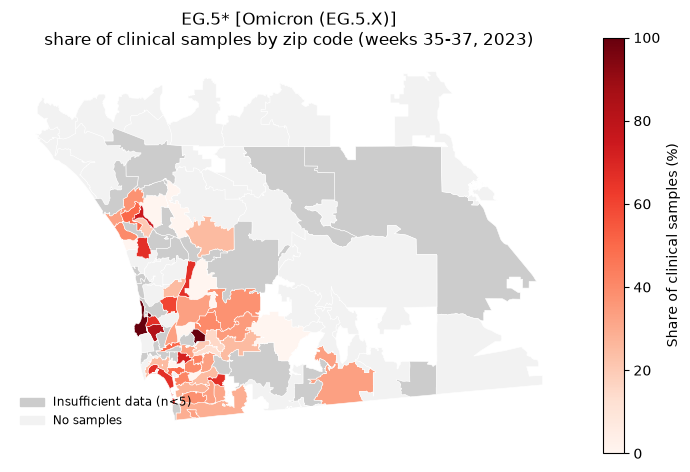

In [30]:
map_df = san_diego_zctas.merge(zip_summary, on="zipcode", how="left")
map_df = gpd.GeoDataFrame(map_df, geometry="geometry")

def zip_color(row):
    if pd.isna(row["n_samples"]):
        return no_data_color
    if not row["reliable"]:
        return insufficient_color
    return eg5_cmap(eg5_norm(row["eg5_pct"]))

fig, ax = plt.subplots(figsize=(9, 9))
map_df.plot(ax=ax, color=map_df.apply(zip_color, axis=1), edgecolor="white", linewidth=0.4)
ax.set_axis_off()
ax.set_title(f"{EG5_NAME}\nshare of clinical samples by zip code (weeks 35-37, 2023)")

sm = mpl.cm.ScalarMappable(cmap=eg5_cmap, norm=eg5_norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label("Share of clinical samples (%)")

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=insufficient_color),
    plt.Rectangle((0, 0), 1, 1, color=no_data_color),
]
ax.legend(legend_handles, ["Insufficient data (n<5)", "No samples"],
          loc="lower left", fontsize="small", frameon=False)
plt.show()

#### Load the wastewater metadata and Freyja lineage abundances
As in Step 2, wastewater samples are a pooled mixture rather than one lineage per sample. `wastewater_metadata.csv` gives each sample's collection date and treatment plant `location` (Point Loma, South Bay, or Encina); each sample's deconvolved lineage mixture lives in its own `.demix.tsv` file under `../data/freyja_demix/`, produced by [Freyja](https://github.com/andersen-lab/Freyja). We read all of them into one long table of `(sample_id, lineage, abundance)`, same as Step 2, and compute the same `year_week` column used above.

In [31]:
wastewater_metadata = pd.read_csv("../data/wastewater_metadata.csv")
wastewater_metadata["year_week"] = pd.to_datetime(wastewater_metadata["collection_date"]).dt.strftime("%G-W%V")

demix_dir = "../data/freyja_demix"
records = []
for filename in os.listdir(demix_dir):
    if not filename.endswith(".demix.tsv"):
        continue
    sample_id = filename.replace(".demix.tsv", "")
    demix = pd.read_csv(os.path.join(demix_dir, filename), sep="\t", header=None, index_col=0)
    lineages = demix.loc["lineages"].dropna().iloc[0].split()
    abundances = [float(x) for x in demix.loc["abundances"].dropna().iloc[0].split()]
    for lineage, abundance in zip(lineages, abundances):
        records.append((sample_id, lineage, abundance))

wastewater_long = pd.DataFrame(records, columns=["sample_id", "lineage", "abundance"])
wastewater_long.head()

,sample_id,lineage,abundance
0,10.11.23.SBOCT08.R1.rerun__NA__NA__231023_WW__00X,HV.1,0.342975
1,10.11.23.SBOCT08.R1.rerun__NA__NA__231023_WW__00X,XBB.1.16.6,0.100350
2,10.11.23.SBOCT08.R1.rerun__NA__NA__231023_WW__00X,EG.2,0.090619
3,10.11.23.SBOCT08.R1.rerun__NA__NA__231023_WW__00X,HZ.1,0.073364
4,10.11.23.SBOCT08.R1.rerun__NA__NA__231023_WW__00X,HS.1.1,0.068563


#### Roll wastewater lineages into EG.5* share by facility
We reuse the exact `lineage_to_variant` mapping built earlier for the clinical data, so wastewater and clinical samples are grouped identically and stay comparable. Each sample's per-lineage abundances are summed into their variant family and renormalized to 100%, restricted to the same weeks 35-38 window, then averaged across all samples collected at the same treatment plant location.

In [32]:
wastewater_long["variant"] = wastewater_long["lineage"].map(lineage_to_variant).fillna("Other")

per_sample_variant = wastewater_long.groupby(["sample_id", "variant"])["abundance"].sum().unstack(fill_value=0)
per_sample_variant_pct = per_sample_variant.div(per_sample_variant.sum(axis=1), axis=0) * 100
if EG5_NAME not in per_sample_variant_pct.columns:
    per_sample_variant_pct[EG5_NAME] = 0.0

sample_location = wastewater_metadata.set_index("sample_id")["location"]
sample_year_week = wastewater_metadata.set_index("sample_id")["year_week"]
per_sample_variant_pct["location"] = per_sample_variant_pct.index.map(sample_location)
per_sample_variant_pct["year_week"] = per_sample_variant_pct.index.map(sample_year_week)

wastewater_window = per_sample_variant_pct[per_sample_variant_pct["year_week"].isin(ANALYSIS_WEEKS)]
facility_summary = wastewater_window.groupby("location").agg(
    eg5_pct=(EG5_NAME, "mean"),
    n_samples=(EG5_NAME, "size"),
)
facility_summary

,eg5_pct,n_samples
location,,
Encina,34.370202,6
Point Loma,34.208431,13
South Bay,23.259942,8


#### Plot 2: EG.5* share of wastewater signal by treatment plant location
![Map of the Encina, Point Loma, and South Bay wastewater treatment plant service areas in San Diego County](ww_sd.png)

*Each `location` corresponds to one of these three treatment plant service areas, shown above.*

A bar per treatment plant, colored on the exact same red colormap and 0-100% scale as Plot 1, so the two plots can be compared directly. Each bar is labeled with the number of samples (`n`) it's based on.

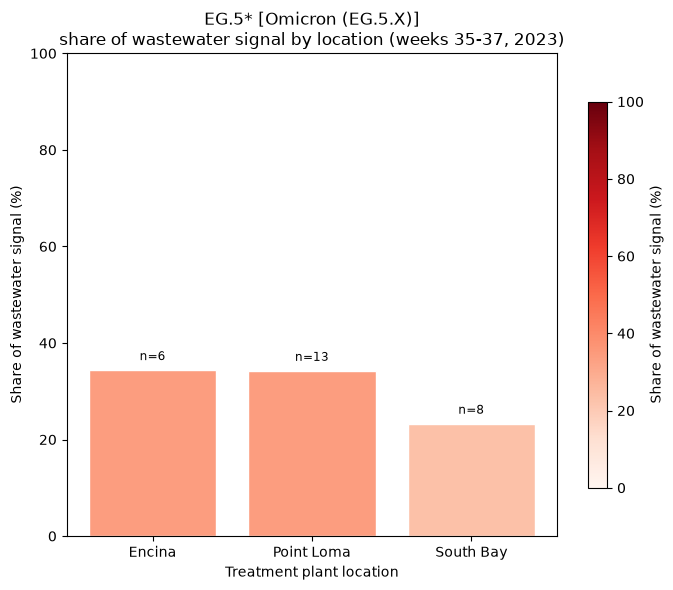

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
bar_colors = [eg5_cmap(eg5_norm(v)) for v in facility_summary["eg5_pct"]]
bars = ax.bar(facility_summary.index, facility_summary["eg5_pct"], color=bar_colors, edgecolor="white")

for bar, n in zip(bars, facility_summary["n_samples"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"n={n}",
            ha="center", va="bottom", fontsize="small")

ax.set_ylim(0, 100)
ax.set_ylabel("Share of wastewater signal (%)")
ax.set_xlabel("Treatment plant location")
ax.set_title(f"{EG5_NAME}\nshare of wastewater signal by location (weeks 35-37, 2023)")

sm = mpl.cm.ScalarMappable(cmap=eg5_cmap, norm=eg5_norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("Share of wastewater signal (%)")

plt.tight_layout()
plt.show()